# Homework: Implementing Optimization Methods in PyTorch

**Course:** NLP
**Topic:** Optimization Methods  
**Total Points:** 100 + 15 Bonus

---

## Instructions

In this homework, you will implement several optimization algorithms from scratch using PyTorch's `torch.optim.Optimizer` base class. Each optimizer has skeleton code with `TODO` markers indicating where you need to add your implementation.

### What You Need to Do:

1. **Read the mathematical background** for each optimizer carefully
2. **Fill in the missing code** where you see `TODO` comments
3. **Run the test cells** to verify your implementation
4. **Compare with PyTorch's built-in optimizers** to validate correctness

### Submission Guidelines:

- Submit the completed notebook with all cells executed
- Ensure all test cells pass without errors
- Include any additional analysis or observations in the designated cells

### Academic Integrity:

- You may refer to the lecture notes and PyTorch documentation
- Do NOT copy code directly from PyTorch's source or other implementations
- Collaboration is allowed for discussion, but code must be your own

---

## Grading Rubric

| Task | Points | Criteria |
|------|--------|----------|
| **1. Gradient Descent** | **20 pts** | |
| - Correct update rule | 10 pts | `p.add_(grad, alpha=-lr)` or equivalent |
| - Proper use of param_groups | 5 pts | Iterating over `self.param_groups` and `group['params']` |
| - Gradient check | 3 pts | Checking `if p.grad is None` |
| - Closure support | 2 pts | Handling optional closure argument |
| **2. Momentum** | **25 pts** | |
| - Velocity initialization | 5 pts | Creating zero tensor in `self.state[p]` |
| - Velocity update | 10 pts | `v = momentum * v + grad` |
| - Parameter update | 8 pts | `p = p - lr * v` |
| - State management | 2 pts | Proper use of `self.state` dictionary |
| **3. Nesterov Accelerated Gradient** | **25 pts** | |
| - Velocity update | 8 pts | Correct momentum accumulation |
| - Nesterov correction | 12 pts | `p = p - lr * (grad + momentum * v)` |
| - Optional schedule | 5 pts | Implementing `mu_k = 1 - 3/(k+5)` |
| **4. ADAM** | **30 pts** | |
| - First moment (m) update | 7 pts | `m = beta1 * m + (1 - beta1) * grad` |
| - Second moment (v) update | 7 pts | `v = beta2 * v + (1 - beta2) * grad^2` |
| - Bias correction | 8 pts | `m_hat = m / (1 - beta1^t)`, `v_hat = v / (1 - beta2^t)` |
| - Parameter update | 6 pts | `p = p - lr * m_hat / (sqrt(v_hat) + eps)` |
| - Step counter | 2 pts | Proper initialization and incrementing |
| **Bonus: RMSprop** | **+15 pts** | |
| - Square gradient average | 5 pts | `v = alpha * v + (1 - alpha) * grad^2` |
| - Adaptive learning rate | 5 pts | `p = p - lr * grad / (sqrt(v) + eps)` |
| - Correct implementation | 5 pts | Matches PyTorch behavior |

### Grading Notes:

- **Full credit**: Implementation is correct and matches PyTorch's behavior
- **Partial credit**: Logic is correct but minor bugs exist
- **No credit**: Missing implementation or fundamentally incorrect
- **Code style**: Clean, well-commented code may receive up to 5 bonus points

---

## Setup

Run this cell first to import necessary libraries.

In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Plotting style
plt.rcParams['figure.figsize'] = [12, 5]
plt.rcParams['font.size'] = 11

print(f"PyTorch version: {torch.__version__}")
print("Setup complete!")

PyTorch version: 2.14.1+cu130
Setup complete!


## Test Functions

We will use these functions to test your optimizer implementations.

In [14]:
def quadratic_function(params, a=1.0, b=10.0):
    """Quadratic bowl: f(x,y) = 0.5*(a*x^2 + b*y^2). Minimum at (0, 0)"""
    x, y = params[0], params[1]
    return 0.5 * (a * x**2 + b * y**2)

def rosenbrock_function(params, a=1.0, b=100.0):
    """Rosenbrock: f(x,y) = (a-x)^2 + b*(y-x^2)^2. Minimum at (1, 1)"""
    x, y = params[0], params[1]
    return (a - x)**2 + b * (y - x**2)**2

def optimize_and_track(optimizer_class, func, init_point, n_steps=100, **opt_kwargs):
    """
    Run optimization and track the trajectory.
    
    Args:
        optimizer_class: Optimizer class (custom or PyTorch built-in)
        func: Objective function
        init_point: Starting point [x, y]
        n_steps: Number of steps
        **opt_kwargs: Optimizer arguments
    
    Returns:
        trajectory: Array of points visited
        losses: Array of loss values
    """
    params = torch.tensor(init_point, dtype=torch.float32, requires_grad=True)
    optimizer = optimizer_class([params], **opt_kwargs)
    
    trajectory = [params.detach().clone().numpy()]
    losses = []
    
    for _ in range(n_steps):
        optimizer.zero_grad()
        loss = func(params)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
        trajectory.append(params.detach().clone().numpy())
    
    return np.array(trajectory), np.array(losses)

def compare_optimizers(custom_opt, pytorch_opt, func, init_point, n_steps, 
                       custom_kwargs, pytorch_kwargs, title=""):
    """Compare custom optimizer with PyTorch's implementation"""
    traj_custom, losses_custom = optimize_and_track(
        custom_opt, func, init_point, n_steps, **custom_kwargs
    )
    traj_pytorch, losses_pytorch = optimize_and_track(
        pytorch_opt, func, init_point, n_steps, **pytorch_kwargs
    )
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss comparison
    axes[0].semilogy(losses_custom, 'b-', linewidth=2, label='Your Implementation')
    axes[0].semilogy(losses_pytorch, 'r--', linewidth=2, label='PyTorch')
    axes[0].set_xlabel('Iteration')
    axes[0].set_ylabel('Loss (log scale)')
    axes[0].set_title(f'{title} - Loss Comparison')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Trajectory comparison
    axes[1].plot(traj_custom[:, 0], traj_custom[:, 1], 'b.-', linewidth=1.5, 
                 markersize=3, label='Your Implementation')
    axes[1].plot(traj_pytorch[:, 0], traj_pytorch[:, 1], 'r.--', linewidth=1.5, 
                 markersize=3, label='PyTorch')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('y')
    axes[1].set_title(f'{title} - Trajectory')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Check if implementations match
    loss_diff = np.abs(losses_custom[-1] - losses_pytorch[-1])
    print(f"Final loss (Your impl): {losses_custom[-1]:.8f}")
    print(f"Final loss (PyTorch):   {losses_pytorch[-1]:.8f}")
    print(f"Difference: {loss_diff:.2e}")
    
    if loss_diff < 1e-4:
        print("\n✅ PASSED: Your implementation matches PyTorch!")
        return True
    else:
        print("\n❌ FAILED: Results don't match. Check your implementation.")
        return False

---

# Task 1: Gradient Descent (20 points)

## Mathematical Background

Gradient descent updates parameters by moving in the direction of steepest descent:

$$x_{k+1} = x_k - \epsilon \nabla f(x_k)$$

where:
- $x_k$ is the current parameter
- $\epsilon$ (lr) is the learning rate
- $\nabla f(x_k)$ is the gradient

## Your Task

Complete the `step()` method in the `GradientDescent` class below.

### Hints:
- Use `p.add_(tensor, alpha=scalar)` for in-place addition: `p = p + alpha * tensor`
- Access learning rate via `group['lr']`
- Access gradient via `p.grad`

In [15]:
class GradientDescent(torch.optim.Optimizer):
    """
    Vanilla Gradient Descent optimizer.
    
    Update rule: x_{k+1} = x_k - lr * grad
    """
    
    def __init__(self, params, lr=0.01):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        defaults = dict(lr=lr)
        super(GradientDescent, self).__init__(params, defaults)
    
    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single optimization step.
        
        Args:
            closure: A callable that reevaluates the model and returns the loss (optional)
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        
        for group in self.param_groups:
            lr = group['lr']
            
            for p in group['params']:
                # Parameters that took no part in the loss have no gradient
                if p.grad is None:
                    continue
                
                # Step against the gradient: p = p - lr * grad
                p.add_(p.grad, alpha=-lr)
        
        return loss

### Test Your Gradient Descent Implementation

Testing Gradient Descent on Quadratic Function...


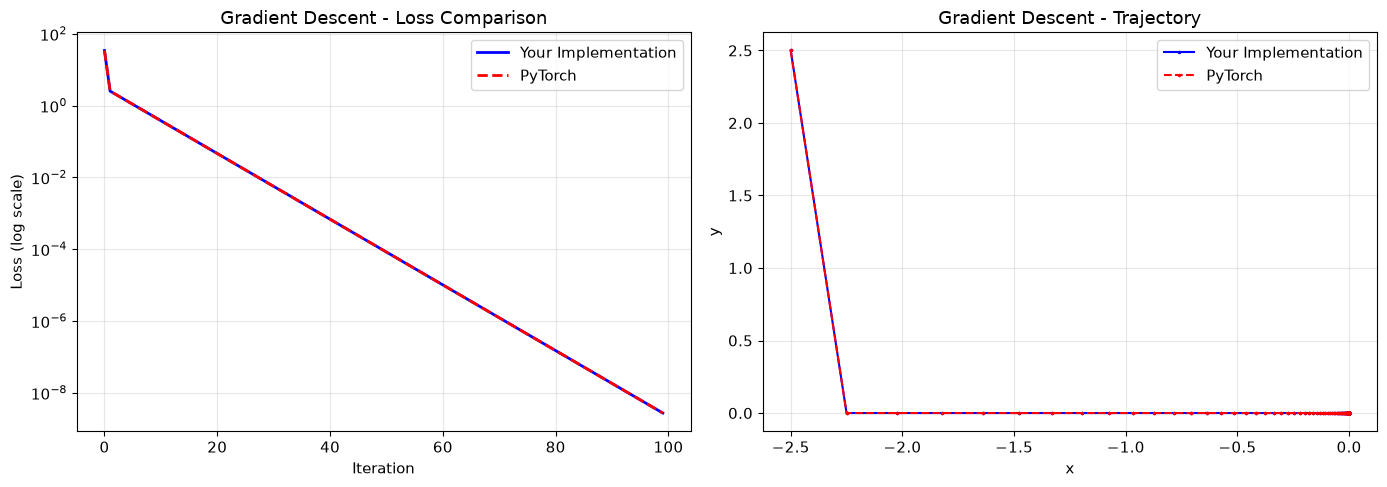

Final loss (Your impl): 0.00000000
Final loss (PyTorch):   0.00000000
Difference: 0.00e+00

✅ PASSED: Your implementation matches PyTorch!


In [16]:
# Test 1: Compare with PyTorch's SGD (without momentum = gradient descent)
print("Testing Gradient Descent on Quadratic Function...")
print("="*50)

test_passed = compare_optimizers(
    custom_opt=GradientDescent,
    pytorch_opt=optim.SGD,
    func=quadratic_function,
    init_point=[-2.5, 2.5],
    n_steps=100,
    custom_kwargs={'lr': 0.1},
    pytorch_kwargs={'lr': 0.1},
    title="Gradient Descent"
)

---

# Task 2: SGD with Momentum (25 points)

## Mathematical Background

Momentum accelerates gradient descent by accumulating a velocity vector:

$$v_{k+1} = \mu \cdot v_k + g_k$$
$$x_{k+1} = x_k - \epsilon \cdot v_{k+1}$$

where:
- $v_k$ is the velocity (momentum buffer)
- $\mu$ is the momentum coefficient (typically 0.9)
- $g_k = \nabla f(x_k)$ is the gradient

### Key Insight:
Momentum acts like a moving average of gradients, helping to:
- Accelerate in consistent gradient directions
- Dampen oscillations
- Escape shallow local minima

## Your Task

Complete the `step()` method. You need to:
1. Initialize velocity buffer in `self.state[p]` if it doesn't exist
2. Update velocity: `v = momentum * v + grad`
3. Update parameter: `p = p - lr * v`

In [17]:
class MomentumSGD(torch.optim.Optimizer):
    """
    SGD with Momentum optimizer.
    
    Update rule:
        v = momentum * v + grad
        x = x - lr * v
    """
    
    def __init__(self, params, lr=0.01, momentum=0.9):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if momentum < 0.0:
            raise ValueError(f"Invalid momentum: {momentum}")
        
        defaults = dict(lr=lr, momentum=momentum)
        super(MomentumSGD, self).__init__(params, defaults)
    
    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single optimization step with momentum.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        
        for group in self.param_groups:
            lr = group['lr']
            momentum = group['momentum']
            
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad
                
                # Velocity persists between steps; it starts at zero
                param_state = self.state[p]
                if 'velocity' not in param_state:
                    param_state['velocity'] = torch.zeros_like(p)
                velocity = param_state['velocity']
                
                # v = momentum * v + grad
                velocity.mul_(momentum).add_(grad)
                
                # p = p - lr * v
                p.add_(velocity, alpha=-lr)
        
        return loss

### Test Your Momentum Implementation

Testing Momentum SGD on Quadratic Function...


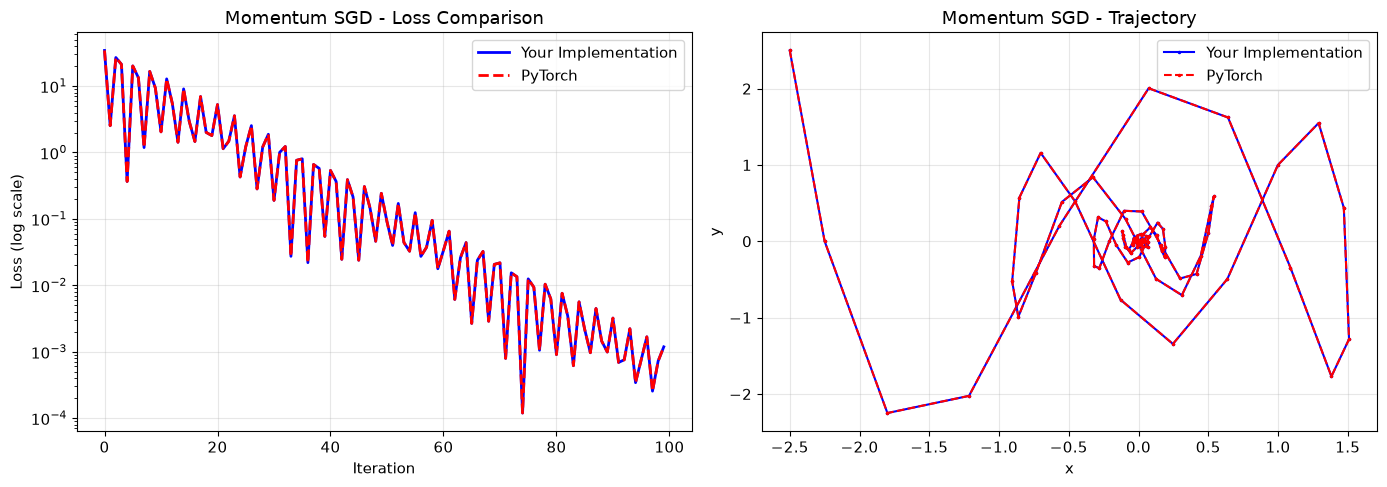

Final loss (Your impl): 0.00118616
Final loss (PyTorch):   0.00118616
Difference: 0.00e+00

✅ PASSED: Your implementation matches PyTorch!


In [18]:
# Test 2: Compare with PyTorch's SGD with momentum
print("Testing Momentum SGD on Quadratic Function...")
print("="*50)

test_passed = compare_optimizers(
    custom_opt=MomentumSGD,
    pytorch_opt=optim.SGD,
    func=quadratic_function,
    init_point=[-2.5, 2.5],
    n_steps=100,
    custom_kwargs={'lr': 0.1, 'momentum': 0.9},
    pytorch_kwargs={'lr': 0.1, 'momentum': 0.9},
    title="Momentum SGD"
)

---

# Task 3: Nesterov Accelerated Gradient (25 points)

## Mathematical Background

Nesterov's method computes the gradient at a "look-ahead" position:

**Original formulation:**
$$v_{k+1} = \mu \cdot v_k - \epsilon \nabla f(x_k + \mu \cdot v_k)$$
$$x_{k+1} = x_k + v_{k+1}$$

**PyTorch's equivalent formulation** (avoids computing gradient at look-ahead):
$$v_{k+1} = \mu \cdot v_k + g_k$$
$$x_{k+1} = x_k - \epsilon (g_k + \mu \cdot v_{k+1})$$

### Key Insight:
Nesterov "looks ahead" before computing the gradient, allowing for course corrections. This leads to faster convergence: $O(1/k^2)$ vs $O(1/k)$ for standard GD.

### Optional Nesterov Schedule:
$$\mu_k = 1 - \frac{3}{k + 5}$$

## Your Task

Complete the Nesterov update. The key difference from momentum is the parameter update formula.

In [19]:
class NesterovSGD(torch.optim.Optimizer):
    """
    Nesterov's Accelerated Gradient optimizer.
    
    Update rule (PyTorch style):
        v = momentum * v + grad
        x = x - lr * (grad + momentum * v)
    """
    
    def __init__(self, params, lr=0.01, momentum=0.9, use_nesterov_schedule=False):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if momentum < 0.0:
            raise ValueError(f"Invalid momentum: {momentum}")
        
        defaults = dict(lr=lr, momentum=momentum, use_nesterov_schedule=use_nesterov_schedule)
        super(NesterovSGD, self).__init__(params, defaults)
        self.step_count = 0
    
    def _get_momentum(self, base_momentum, use_schedule):
        """Get momentum value, optionally using Nesterov's schedule."""
        if use_schedule:
            # mu_k = 1 - 3 / (k + 5): starts at 0.4 and grows towards 1
            return 1 - 3 / (self.step_count + 5)
        return base_momentum
    
    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single Nesterov optimization step.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        
        for group in self.param_groups:
            lr = group['lr']
            momentum = self._get_momentum(group['momentum'], group['use_nesterov_schedule'])
            
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad
                
                # Get or create velocity buffer
                param_state = self.state[p]
                if 'velocity' not in param_state:
                    param_state['velocity'] = torch.zeros_like(p)
                velocity = param_state['velocity']
                
                # v = momentum * v + grad
                velocity.mul_(momentum).add_(grad)
                
                # Nesterov correction: p = p - lr * (grad + momentum * v)
                p.add_(grad + momentum * velocity, alpha=-lr)
        
        self.step_count += 1
        return loss

### Test Your Nesterov Implementation

Testing Nesterov SGD on Quadratic Function...


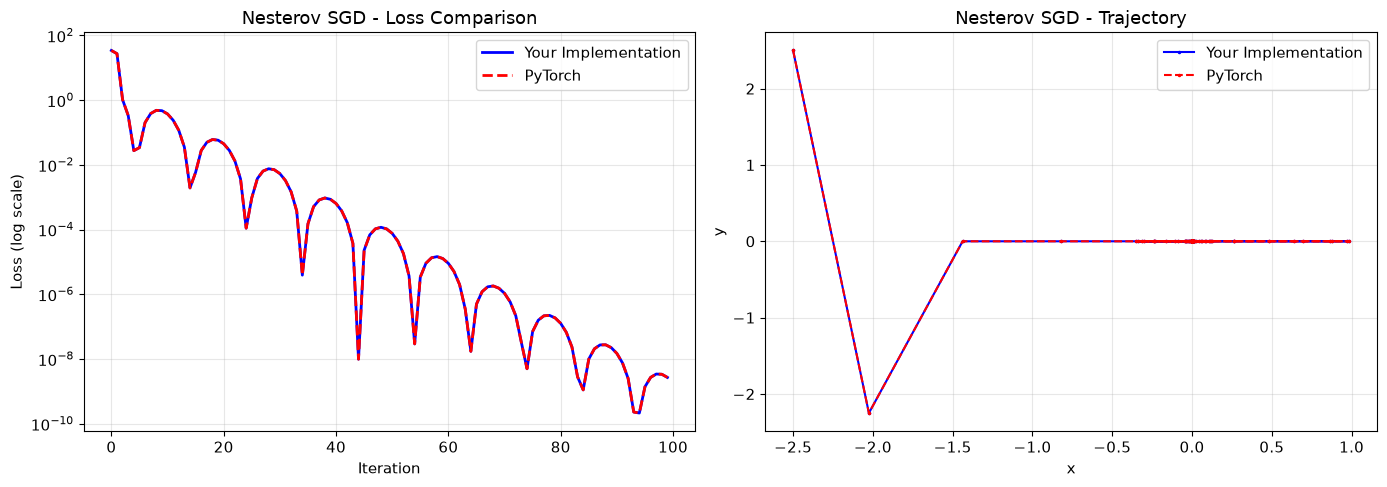

Final loss (Your impl): 0.00000000
Final loss (PyTorch):   0.00000000
Difference: 0.00e+00

✅ PASSED: Your implementation matches PyTorch!


In [20]:
# Test 3: Compare with PyTorch's SGD with Nesterov momentum
print("Testing Nesterov SGD on Quadratic Function...")
print("="*50)

test_passed = compare_optimizers(
    custom_opt=NesterovSGD,
    pytorch_opt=optim.SGD,
    func=quadratic_function,
    init_point=[-2.5, 2.5],
    n_steps=100,
    custom_kwargs={'lr': 0.1, 'momentum': 0.9},
    pytorch_kwargs={'lr': 0.1, 'momentum': 0.9, 'nesterov': True},
    title="Nesterov SGD"
)

---

# Task 4: ADAM (30 points)

## Mathematical Background

ADAM (Adaptive Moment Estimation) combines momentum with adaptive learning rates:

**First moment (mean of gradients):**
$$m_k = \beta_1 \cdot m_{k-1} + (1 - \beta_1) \cdot g_k$$

**Second moment (mean of squared gradients):**
$$v_k = \beta_2 \cdot v_{k-1} + (1 - \beta_2) \cdot g_k^2$$

**Bias correction** (because $m_0 = v_0 = 0$):
$$\hat{m}_k = \frac{m_k}{1 - \beta_1^k}, \quad \hat{v}_k = \frac{v_k}{1 - \beta_2^k}$$

**Parameter update:**
$$x_{k+1} = x_k - \frac{\epsilon}{\sqrt{\hat{v}_k} + \gamma} \cdot \hat{m}_k$$

### Default hyperparameters:
- $\beta_1 = 0.9$ (momentum for gradient)
- $\beta_2 = 0.999$ (momentum for squared gradient)
- $\gamma = 10^{-8}$ (epsilon for numerical stability)

### Key Insight:
Division by $\sqrt{\hat{v}_k}$ creates adaptive per-parameter learning rates.

## Your Task

This is the most complex optimizer. Pay attention to:
1. Maintaining step counter for bias correction
2. Using element-wise operations for squared gradients
3. Correct bias correction formulas

In [21]:
class Adam(torch.optim.Optimizer):
    """
    ADAM optimizer.
    
    Update rule:
        m = beta1 * m + (1 - beta1) * grad
        v = beta2 * v + (1 - beta2) * grad^2
        m_hat = m / (1 - beta1^t)
        v_hat = v / (1 - beta2^t)
        x = x - lr * m_hat / (sqrt(v_hat) + eps)
    """
    
    def __init__(self, params, lr=0.001, betas=(0.9, 0.999), eps=1e-8):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if not 0.0 <= betas[0] < 1.0:
            raise ValueError(f"Invalid beta1: {betas[0]}")
        if not 0.0 <= betas[1] < 1.0:
            raise ValueError(f"Invalid beta2: {betas[1]}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon: {eps}")
        
        defaults = dict(lr=lr, betas=betas, eps=eps)
        super(Adam, self).__init__(params, defaults)
    
    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single ADAM optimization step.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        
        for group in self.param_groups:
            lr = group['lr']
            beta1, beta2 = group['betas']
            eps = group['eps']
            
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad
                
                # ============================================================
                # TODO: Initialize state if needed (2 points)
                #
                # If len(self.state[p]) == 0 (first time for this param):
                #   - self.state[p]['step'] = 0
                #   - self.state[p]['m'] = torch.zeros_like(p)  # First moment
                #   - self.state[p]['v'] = torch.zeros_like(p)  # Second moment
                # ============================================================
                
                param_state = self.state[p]
                
                # YOUR CODE HERE: Initialize state
                pass
                
                # ============================================================
                
                # Get state variables
                m = param_state['m']
                v = param_state['v']
                param_state['step'] += 1
                step = param_state['step']
                
                # ============================================================
                # TODO: Update first moment estimate (7 points)
                #
                # Formula: m = beta1 * m + (1 - beta1) * grad
                # Use: m.mul_(beta1).add_(grad, alpha=1 - beta1)
                # ============================================================
                
                # YOUR CODE HERE: Update first moment
                pass
                
                # ============================================================
                # TODO: Update second moment estimate (7 points)
                #
                # Formula: v = beta2 * v + (1 - beta2) * grad^2
                # Use: v.mul_(beta2).addcmul_(grad, grad, value=1 - beta2)
                # Note: addcmul_ does: v = v + value * (tensor1 * tensor2)
                # ============================================================
                
                # YOUR CODE HERE: Update second moment
                pass
                
                # ============================================================
                # TODO: Compute bias corrections (8 points)
                #
                # bias_correction1 = 1 - beta1 ** step
                # bias_correction2 = 1 - beta2 ** step
                # m_hat = m / bias_correction1
                # v_hat = v / bias_correction2
                # ============================================================
                
                # YOUR CODE HERE: Bias correction
                pass
                
                # ============================================================
                # TODO: Update parameters (6 points)
                #
                # Formula: p = p - lr * m_hat / (sqrt(v_hat) + eps)
                # Use: p.addcdiv_(m_hat, v_hat.sqrt().add_(eps), value=-lr)
                # Note: addcdiv_ does: p = p + value * (tensor1 / tensor2)
                # ============================================================
                
                # YOUR CODE HERE: Parameter update
                pass
                
                # ============================================================
                # END OF YOUR CODE
                # ============================================================
        
        return loss

### Test Your ADAM Implementation

In [22]:
# Test 4: Compare with PyTorch's Adam
print("Testing Adam on Quadratic Function...")
print("="*50)

test_passed = compare_optimizers(
    custom_opt=Adam,
    pytorch_opt=optim.Adam,
    func=quadratic_function,
    init_point=[-2.5, 2.5],
    n_steps=100,
    custom_kwargs={'lr': 0.5, 'betas': (0.9, 0.999)},
    pytorch_kwargs={'lr': 0.5, 'betas': (0.9, 0.999)},
    title="Adam"
)

Testing Adam on Quadratic Function...


KeyError: 'm'

In [ ]:
# Additional test: Rosenbrock function (more challenging)
print("\nTesting Adam on Rosenbrock Function...")
print("="*50)

test_passed = compare_optimizers(
    custom_opt=Adam,
    pytorch_opt=optim.Adam,
    func=rosenbrock_function,
    init_point=[-1.0, 2.0],
    n_steps=2000,
    custom_kwargs={'lr': 0.01, 'betas': (0.9, 0.999)},
    pytorch_kwargs={'lr': 0.01, 'betas': (0.9, 0.999)},
    title="Adam (Rosenbrock)"
)

---

# Bonus Task: RMSprop (+15 points)

## Mathematical Background

RMSprop (Root Mean Square Propagation) adapts learning rates using a moving average of squared gradients:

$$v_k = \alpha \cdot v_{k-1} + (1 - \alpha) \cdot g_k^2$$
$$x_{k+1} = x_k - \frac{\epsilon}{\sqrt{v_k} + \gamma} \cdot g_k$$

where:
- $\alpha$ is the decay rate (typically 0.99)
- $\gamma$ (eps) is for numerical stability

### Key Insight:
RMSprop is like ADAM without the first moment (momentum). It's the foundation for ADAM's adaptive learning rate.

In [ ]:
class RMSprop(torch.optim.Optimizer):
    """
    RMSprop optimizer.
    
    Update rule:
        v = alpha * v + (1 - alpha) * grad^2
        x = x - lr * grad / (sqrt(v) + eps)
    """
    
    def __init__(self, params, lr=0.01, alpha=0.99, eps=1e-8):
        if lr < 0.0:
            raise ValueError(f"Invalid learning rate: {lr}")
        if alpha < 0.0 or alpha >= 1.0:
            raise ValueError(f"Invalid alpha: {alpha}")
        if eps < 0.0:
            raise ValueError(f"Invalid epsilon: {eps}")
        
        defaults = dict(lr=lr, alpha=alpha, eps=eps)
        super(RMSprop, self).__init__(params, defaults)
    
    @torch.no_grad()
    def step(self, closure=None):
        """
        Performs a single RMSprop optimization step.
        """
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()
        
        for group in self.param_groups:
            lr = group['lr']
            alpha = group['alpha']
            eps = group['eps']
            
            for p in group['params']:
                if p.grad is None:
                    continue
                
                grad = p.grad
                param_state = self.state[p]
                
                # ============================================================
                # BONUS TODO: Implement RMSprop (15 points)
                #
                # Step 1 (5 pts): Initialize/get square average buffer
                #   If 'square_avg' not in param_state:
                #     param_state['square_avg'] = torch.zeros_like(p)
                #   v = param_state['square_avg']
                #
                # Step 2 (5 pts): Update square average
                #   v = alpha * v + (1 - alpha) * grad^2
                #   Use: v.mul_(alpha).addcmul_(grad, grad, value=1 - alpha)
                #
                # Step 3 (5 pts): Update parameters
                #   p = p - lr * grad / (sqrt(v) + eps)
                #   Use: p.addcdiv_(grad, v.sqrt().add_(eps), value=-lr)
                # ============================================================
                
                # YOUR CODE HERE
                pass
                
                # ============================================================
                # END OF YOUR CODE
                # ============================================================
        
        return loss

### Test Your RMSprop Implementation

In [ ]:
# Test Bonus: Compare with PyTorch's RMSprop
print("Testing RMSprop on Quadratic Function...")
print("="*50)

test_passed = compare_optimizers(
    custom_opt=RMSprop,
    pytorch_opt=optim.RMSprop,
    func=quadratic_function,
    init_point=[-2.5, 2.5],
    n_steps=100,
    custom_kwargs={'lr': 0.1, 'alpha': 0.99},
    pytorch_kwargs={'lr': 0.1, 'alpha': 0.99},
    title="RMSprop"
)

---

# Final Comparison: All Optimizers

Run this cell after completing all implementations to see how they compare.

In [ ]:
# Compare all implemented optimizers
print("\n" + "="*60)
print("FINAL COMPARISON: All Optimizers on Quadratic Function")
print("="*60 + "\n")

init_point = [-2.5, 2.5]
n_steps = 100

optimizers_to_test = {
    'Gradient Descent': (GradientDescent, {'lr': 0.1}),
    'Momentum': (MomentumSGD, {'lr': 0.1, 'momentum': 0.9}),
    'Nesterov': (NesterovSGD, {'lr': 0.1, 'momentum': 0.9}),
    'Adam': (Adam, {'lr': 0.5, 'betas': (0.9, 0.999)}),
}

# Add RMSprop if implemented (bonus)
try:
    # Quick test to see if RMSprop is implemented
    test_param = torch.tensor([1.0], requires_grad=True)
    test_param.grad = torch.tensor([1.0])
    test_opt = RMSprop([test_param], lr=0.1)
    test_opt.step()
    if test_param.item() != 1.0:  # If param changed, implementation exists
        optimizers_to_test['RMSprop (Bonus)'] = (RMSprop, {'lr': 0.1, 'alpha': 0.99})
except:
    pass

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = plt.cm.tab10(np.linspace(0, 1, len(optimizers_to_test)))

for (name, (opt_class, opt_kwargs)), color in zip(optimizers_to_test.items(), colors):
    try:
        traj, losses = optimize_and_track(opt_class, quadratic_function, init_point, n_steps, **opt_kwargs)
        axes[0].semilogy(losses, color=color, linewidth=2, label=name)
        axes[1].plot(traj[:, 0], traj[:, 1], '.-', color=color, linewidth=1.5, markersize=3, label=name)
        print(f"{name:20s}: Final loss = {losses[-1]:.8f}")
    except Exception as e:
        print(f"{name:20s}: ERROR - {str(e)[:50]}")

axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Convergence Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(0, 0, 'k*', markersize=15, label='Minimum')
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Optimization Trajectories')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Analysis Questions (Answer in the cell below)

After completing the implementations, answer the following questions:

1. **Convergence Speed**: Which optimizer converged fastest on the quadratic function? Why do you think this is?

2. **Oscillation**: Which optimizers showed oscillating behavior? How does momentum help with this?

3. **Adaptive Learning Rates**: How does ADAM's per-parameter adaptive learning rate help compared to fixed learning rates?

4. **When to Use What**: Based on your experiments, when would you choose:
   - SGD with momentum?
   - Nesterov?
   - Adam?

## Your Answers:

*Double-click this cell to edit and write your answers here*

**1. Convergence Speed:**

[Your answer here]

**2. Oscillation:**

[Your answer here]

**3. Adaptive Learning Rates:**

[Your answer here]

**4. When to Use What:**

[Your answer here]

---

## Submission Checklist

Before submitting, make sure:

- [ ] All `TODO` sections are completed
- [ ] All test cells pass (show ✅ PASSED)
- [ ] The final comparison cell runs without errors
- [ ] Analysis questions are answered
- [ ] All cells have been executed (Kernel → Restart & Run All)

---

## Grading Summary

| Task | Points | Your Score |
|------|--------|------------|
| Gradient Descent | 20 | |
| Momentum SGD | 25 | |
| Nesterov SGD | 25 | |
| ADAM | 30 | |
| **Total** | **100** | |
| RMSprop (Bonus) | +15 | |
| Code Style (Bonus) | +5 | |
| **Grand Total** | **120** | |